<a href="https://colab.research.google.com/github/rizkiismail9a/data-science-2026-unsia/blob/main/pertemuan_12_MuhamadRizkiIsmail_240401010126.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    support       itemsets
1  0.666667         (Roti)
4  0.666667         (Susu)
5  0.500000        (Telur)
8  0.333333  (Selai, Roti)
2  0.333333        (Selai)

      antecedents    consequents   support  confidence  lift
15         (Keju)  (Telur, Susu)  0.166667         1.0   3.0
12  (Telur, Susu)         (Keju)  0.166667         0.5   3.0
8          (Keju)        (Telur)  0.166667         1.0   2.0
14   (Keju, Susu)        (Telur)  0.166667         1.0   2.0
9          (Keju)         (Susu)  0.166667         1.0   1.5


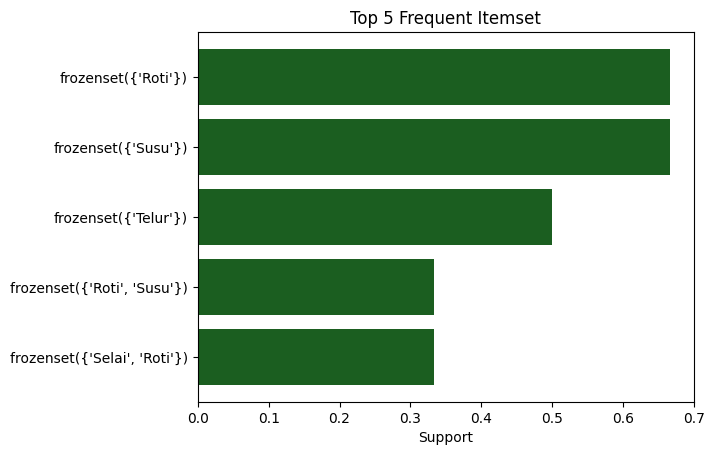

In [ ]:
# -----------------
# Nama: Muhamad Rizki Ismail
# Kelas: IF401
# NIM: 240401010126
# -----------------

# Asosiasi Data & Sistem Rekomendasi Dasar

# Pipeline Lengkap: Market Basket Analysis

# Ignore warning depreciation
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Contoh data
transaksi = [['Roti', 'Susu', 'Telur'], ['Roti', 'Selai'], ['Susu', 'Telur', 'Keju'], ['Roti', 'Susu', 'Selai'], ['Roti', 'Telur'], ['Susu', 'Sereal']]

# One-hot encoding
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Cari Frequent Itemset
freq_items = apriori(df, min_support=0.3, use_colnames=True)
freq_items = freq_items.sort_values(by='support', ascending=False)

print(freq_items.head())
print()

# Bentuk & Saring Aturan Asosiasi
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

# Visualisasi
top = freq_items.sort_values('support').tail(5)
plt.barh(top['itemsets'].astype(str), top['support'], color='#1B5E20')
plt.xlabel('Support'); plt.title('Top 5 Frequent Itemset')
plt.show()

In [4]:
# Hands-On Activity

# Market Basket Analysis & Rekomendasi Produk

import pandas as pd, numpy as np
import matplotlib.pyplot as pyp

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Generate dummy data
transaksi = []

# Buat transaksi dummy, tiap transaksi terdiri dari 2-5 produk
for _ in range(50):
  n_item = np.random.randint(2, 6)
  transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
  if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
    transaksi[i].append('Selai')

print('Contoh Transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

Contoh Transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50


In [6]:
# Preprocessing

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)

print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


In [8]:
# Cari frequensi itemset dengan apriori

from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
  freq = apriori(df, min_support=ms, use_colnames=True)
  print(f'min_support={ms}: {len(freq)} itemset ditemukan')

freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print(freq_items.head(10))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Selai, Teh)


In [9]:
# bentuk dan saring aturan asosiasi

from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False) # urutkan berdasarkan nilai lift tertinggi
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

         antecedents consequents  support  confidence      lift
10       (Teh, Keju)     (Telur)     0.12    0.857143  2.380952
15  (Selai, Mentega)      (Kopi)     0.10    0.625000  1.953125
12      (Gula, Roti)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
9       (Telur, Teh)      (Keju)     0.12    0.600000  1.764706


Output tabel menunjukkan 5 aturan asosiasi teratas, diurutkan berdasarkan nilai 'lift' tertinggi. Berikut penjelasannya:

    1. antecedents: Ini adalah item atau set item yang jika dibeli (misalnya, '(Teh, Keju)').
    2. consequents: Ini adalah item atau set item yang kemungkinan besar akan dibeli setelah antecedents dibeli (misalnya, '(Telur)').
    3. support: Menunjukkan seberapa sering itemset (antecedents dan consequents bersama-sama) muncul di semua transaksi. Misalnya, 0.12 untuk aturan pertama berarti (Teh, Keju, Telur) muncul dalam 12% dari semua transaksi.
    3. confidence: Menunjukkan seberapa sering consequents dibeli jika antecedents sudah dibeli. Misalnya, 0.857143 untuk aturan pertama berarti jika pelanggan membeli Teh dan Keju, ada kemungkinan 85.7% mereka juga akan membeli Telur.
    4. lift: Mengukur seberapa besar kemungkinan consequents dibeli jika antecedents dibeli, relatif terhadap probabilitas pembelian consequents secara keseluruhan. Nilai lift lebih besar dari 1 menunjukkan bahwa ada hubungan positif antara antecedents dan consequents. Semakin tinggi nilainya, semakin kuat asosiasinya. Misalnya, 2.380952 untuk aturan pertama menunjukkan bahwa pelanggan 2.38 kali lebih mungkin membeli Telur jika mereka sudah membeli Teh dan Keju, dibandingkan dengan jika mereka tidak membeli Teh dan Keju.

Dari tabel tersebut, kita bisa melihat beberapa pola menarik:

    1. Jika seseorang membeli Teh dan Keju, sangat mungkin mereka juga akan membeli Telur (confidence ~85.7%, lift ~2.38).
    2. Jika seseorang membeli Selai dan Mentega, mereka kemungkinan besar juga akan membeli Kopi (confidence ~62.5%, lift ~1.95).
    3. Jika seseorang membeli Gula dan Roti, mereka pasti akan membeli Selai (confidence 100%, lift ~1.92). Ini adalah aturan yang sangat kuat, kemungkinan karena pola 'Suntikkan pola: Roti sering bersama Selai' yang kita tambahkan sebelumnya mempengaruhi data ini.

Aturan-aturan ini dapat digunakan untuk rekomendasi produk, penataan letak toko, atau promosi penjualan.

In [10]:
# Rekomendasi Sederhana dengan Content-Based Learning

from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery','Bakery','Dairy','Bakery','Dairy',
    'Dairy','Minuman','Bumbu','Minuman','Dairy']
})

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)


def rekomendasi_serupa(nama_produk, top_n=3):
  idx = katalog.index[katalog['produk'] == nama_produk][0]
  skor = list(enumerate(sim_matrix[idx]))
  skor = sorted(skor, key=lambda x: x[1], reverse=True)
  skor = [s for s in skor if s[0] != idx][:top_n]
  return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

print('Mirip dengan Roti:', rekomendasi_serupa('Roti'))

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


In [12]:
# Bandingkan kedua pendekatan
produk_target = 'Roti'

# Dari association rules: cari consequents dari aturan yang antecedent-nya mengandung produk_target
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)]

print('Rekomendasi dari Association Rules:')
print(rules_terkait[['consequents', 'lift']].head())
print()
print('Ini rekomendasi dari Content-Based:', rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:
   consequents      lift
12     (Selai)  1.923077
1      (Selai)  1.322115

Ini rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


Pada cell ini diberikan target produk berupa "Roti". Di sini, Roti adalah antecedent. Berdasarkan rules yang telah dibuat, jika antecedent adalah Roti, maka consequents adalah Selai.

Rekomendasi dari Association Rules:

Ini adalah produk yang sering dibeli bersamaan atau setelah 'Roti', berdasarkan pola pembelian historis. Dalam kasus ini, jika seseorang membeli 'Roti' (atau 'Gula' dan 'Roti'), produk yang paling sering direkomendasikan adalah Selai. Angka lift menunjukkan seberapa kuat asosiasi ini (nilai di atas 1 berarti asosiasi positif).

Rekomendasi dari Content-Based:

['Selai', 'Sereal', 'Susu']

Ini adalah produk yang 'mirip' dengan 'Roti' berdasarkan fitur/kategori yang sama. Karena 'Roti' dikategorikan sebagai 'Bakery' dalam katalog, sistem mencari produk lain dengan kategori 'Bakery'.

Perbandingan dan Kesimpulan:

Untuk produk 'Roti', kedua pendekatan sama-sama merekomendasikan Selai. Ini masuk akal karena dalam data dummy kita, ada pola yang disuntikkan di mana 'Roti' sering bersama 'Selai'.

Association Rules menemukan hubungan berdasarkan perilaku belanja pelanggan (apa yang dibeli bersama). Ini bagus untuk menemukan item pelengkap.
Content-Based menemukan item yang mirip berdasarkan atribut produk (dalam kasus ini, kategori 'Bakery'). Ini bagus untuk menemukan substitusi atau produk serupa.

Dalam skenario ini, 'Selai' adalah item pelengkap yang kuat untuk 'Roti' dari sudut pandang perilaku belanja, dan juga memiliki kategori yang sama ('Bakery') dengan 'Roti', sehingga direkomendasikan oleh kedua sistem.